In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [14]:
df_marketing = pd.read_csv(
    "MARKETING.csv",
    low_memory=False
)

df_marketing.head()

,Marketing,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Leads total,543,178,416,422,967,954,1409,1315,1973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ventas X Mes,12,7,8,13,6,21,17,17,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Desgloce Detallado (Gastos),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_marketing.shape

(175, 56)

In [16]:
marketing = pd.DataFrame({
    'Mes': df_marketing.iloc[5, 1:30].values,
    'Ventas': df_marketing.iloc[3, 1:30].values,
    'Provision': df_marketing.iloc[6, 1:30].values,
    'Leads': df_marketing.iloc[12, 1:30].values,
    'CAP_GENERAL': df_marketing.iloc[13, 1:30].values,
    'CAC_GENERAL': df_marketing.iloc[15, 1:30].values
})

marketing.head(15)

,Mes,Ventas,Provision,Leads,CAP_GENERAL,CAC_GENERAL
0,"Febrero, 24",12,NaN,543,$0,$0
1,"Marzo, 24",7,NaN,178,$0,$0
2,"Abril, 24",8,NaN,416,$0,$0
3,"Mayo, 24",13,NaN,422,$0,$0
4,"Junio, 24",6,NaN,967,$0,$0
5,"Julio, 24",21,NaN,954,$0,$0
6,"Agosto, 24",17,NaN,1409,$0,$0
7,"Septiembre, 24",17,NaN,1315,$0,$0
8,"Octubre, 24",23,NaN,1973,$0,$0
9,"Noviembre, 24",22,NaN,1562,$0,$0


In [17]:
columnas_numericas = [
    'Ventas',
    'Provision',
    'Leads',
    'CAP_GENERAL',
    'CAC_GENERAL'
]

for columna in columnas_numericas:
    
    marketing[columna] = (
        marketing[columna]
        .astype('string')
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    
    marketing[columna] = pd.to_numeric(
        marketing[columna],
        errors='coerce'
    )

In [18]:
marketing.isnull().sum()

Mes             0
Ventas          0
Provision      11
Leads           0
CAP_GENERAL     0
CAC_GENERAL     0
dtype: int64

In [19]:
marketing_reg = marketing.dropna(
    subset=['Provision']
).copy()

marketing_reg.reset_index(
    drop=True,
    inplace=True
)

marketing_reg

,Mes,Ventas,Provision,Leads,CAP_GENERAL,CAC_GENERAL
0,"Enero, 25",26,346790.94,1042,333,13338
1,"Febrero, 25",20,423573.75,561,755,21179
2,"Marzo, 25",30,242750.78,925,262,8092
3,"Abril, 25",30,517105.0,1083,477,17237
4,"Mayo, 25",34,570803.67,815,700,16788
5,"Junio, 25",40,788379.0,1083,728,19709
6,"Julio, 25",36,735500.0,1358,542,20431
7,"Agosto, 25",27,793172.45,1419,559,29377
8,"Septiembre, 25",38,991000.0,1100,901,26079
9,"Octubre, 25",40,1140000.0,1192,956,28500


In [20]:
marketing_reg.isnull().sum()

Mes            0
Ventas         0
Provision      0
Leads          0
CAP_GENERAL    0
CAC_GENERAL    0
dtype: int64

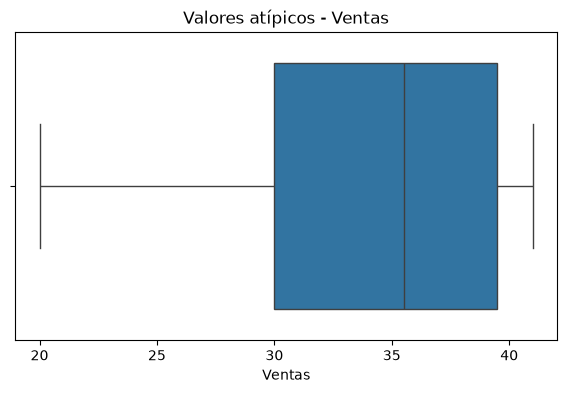

In [21]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x=marketing_reg['Ventas']
)

plt.title('Valores atípicos - Ventas')
plt.xlabel('Ventas')

plt.show()

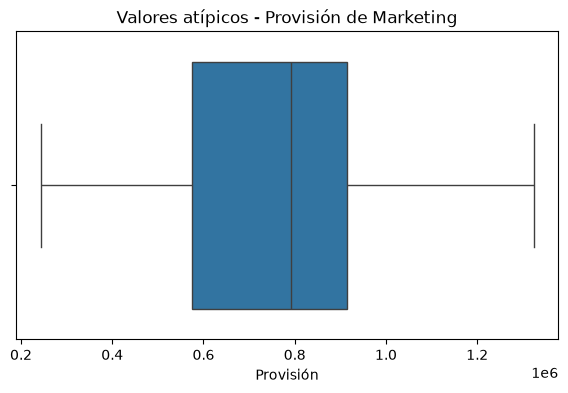

In [22]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x=marketing_reg['Provision']
)

plt.title('Valores atípicos - Provisión de Marketing')
plt.xlabel('Provisión')

plt.show()

In [23]:
Q1 = marketing_reg['Ventas'].quantile(0.25)
Q3 = marketing_reg['Ventas'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers_ventas = marketing_reg[
    (marketing_reg['Ventas'] < limite_inferior) |
    (marketing_reg['Ventas'] > limite_superior)
]

outliers_ventas

Límite inferior: 15.75
Límite superior: 53.75


,Mes,Ventas,Provision,Leads,CAP_GENERAL,CAC_GENERAL


In [24]:
Q1 = marketing_reg['Provision'].quantile(0.25)
Q3 = marketing_reg['Provision'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers_provision = marketing_reg[
    (marketing_reg['Provision'] < limite_inferior) |
    (marketing_reg['Provision'] > limite_superior)
]

outliers_provision

Límite inferior: 63656.88125000015
Límite superior: 1426489.8712499999


,Mes,Ventas,Provision,Leads,CAP_GENERAL,CAC_GENERAL


In [25]:
variables = [
    'Ventas',
    'Provision',
    'Leads',
    'CAP_GENERAL',
    'CAC_GENERAL'
]

correlacion = marketing_reg[variables].corr()

correlacion.round(3)

,Ventas,Provision,Leads,CAP_GENERAL,CAC_GENERAL
Ventas,1.000,0.646,0.523,0.422,0.258
Provision,0.646,1.000,0.660,0.756,0.899
Leads,0.523,0.660,1.000,0.030,0.550
CAP_GENERAL,0.422,0.756,0.030,1.000,0.722
CAC_GENERAL,0.258,0.899,0.550,0.722,1.000


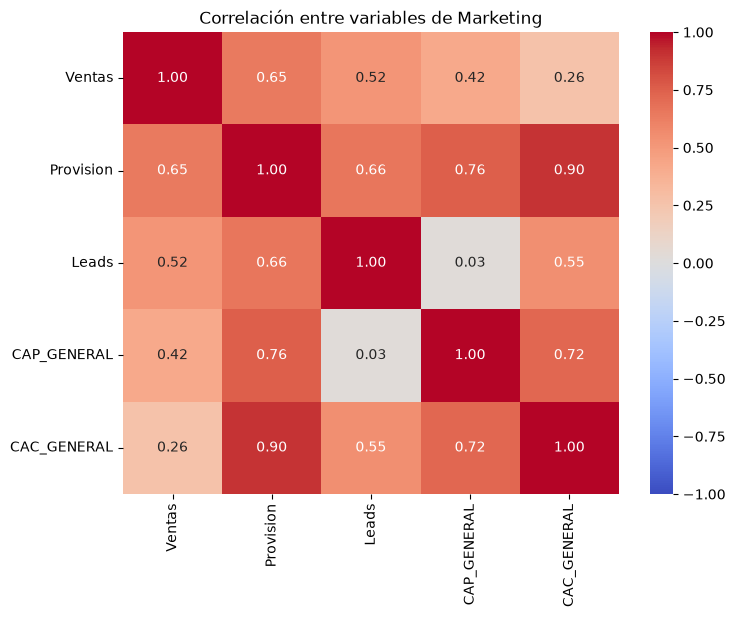

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title('Correlación entre variables de Marketing')

plt.show()

1. PROVISIÓN → VENTAS

In [28]:
X1 = marketing_reg[['Provision']]
y1 = marketing_reg['Ventas']

In [29]:
modelo1 = LinearRegression()

modelo1.fit(X1, y1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Provision']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [30]:
pendiente1 = modelo1.coef_[0]
intercepto1 = modelo1.intercept_
r2_1 = modelo1.score(X1, y1)

print("Pendiente:", pendiente1)
print("Intercepto:", intercepto1)
print("R²:", r2_1)

Pendiente: 1.3294427512271943e-05
Intercepto: 24.05492998806092
R²: 0.41713508532166277


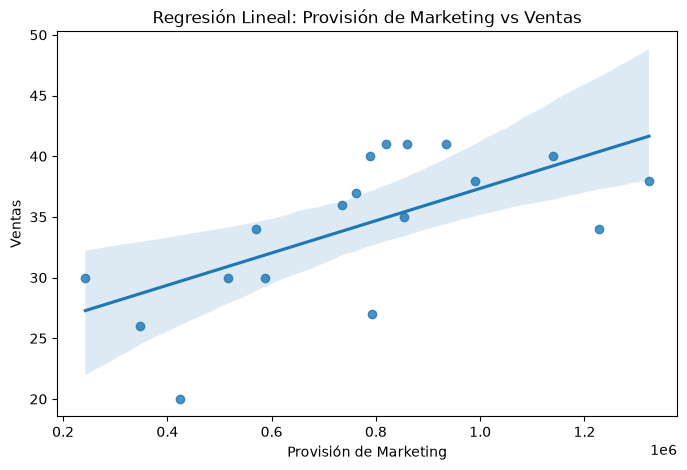

In [31]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=marketing_reg,
    x='Provision',
    y='Ventas'
)

plt.title('Regresión Lineal: Provisión de Marketing vs Ventas')
plt.xlabel('Provisión de Marketing')
plt.ylabel('Ventas')

plt.show()

2. PROVISIÓN → LEADS

In [32]:
X2 = marketing_reg[['Provision']]
y2 = marketing_reg['Leads']

modelo2 = LinearRegression()

modelo2.fit(X2, y2)

pendiente2 = modelo2.coef_[0]
intercepto2 = modelo2.intercept_
r2_2 = modelo2.score(X2, y2)

print("Pendiente:", pendiente2)
print("Intercepto:", intercepto2)
print("R²:", r2_2)

Pendiente: 0.0006443503746471537
Intercepto: 705.6071690631627
R²: 0.4356661441117723


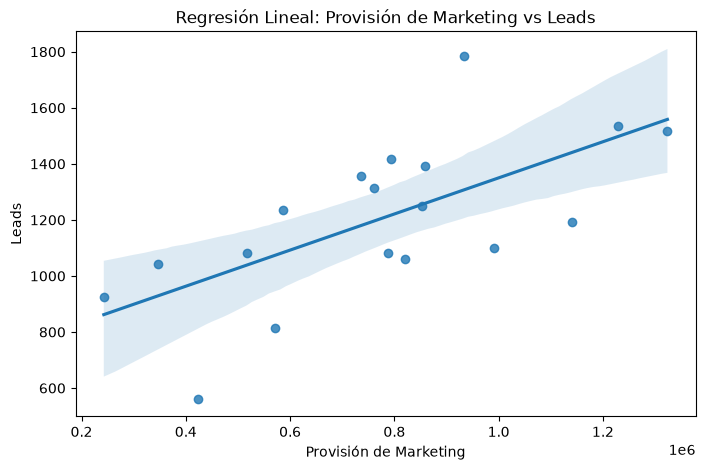

In [33]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=marketing_reg,
    x='Provision',
    y='Leads'
)

plt.title('Regresión Lineal: Provisión de Marketing vs Leads')
plt.xlabel('Provisión de Marketing')
plt.ylabel('Leads')

plt.show()

3. LEADS → VENTAS

In [34]:
X3 = marketing_reg[['Leads']]
y3 = marketing_reg['Ventas']

modelo3 = LinearRegression()

modelo3.fit(X3, y3)

pendiente3 = modelo3.coef_[0]
intercepto3 = modelo3.intercept_
r2_3 = modelo3.score(X3, y3)

print("Pendiente:", pendiente3)
print("Intercepto:", intercepto3)
print("R²:", r2_3)

Pendiente: 0.011029974197101514
Intercepto: 21.055695505400244
R²: 0.273638241586587


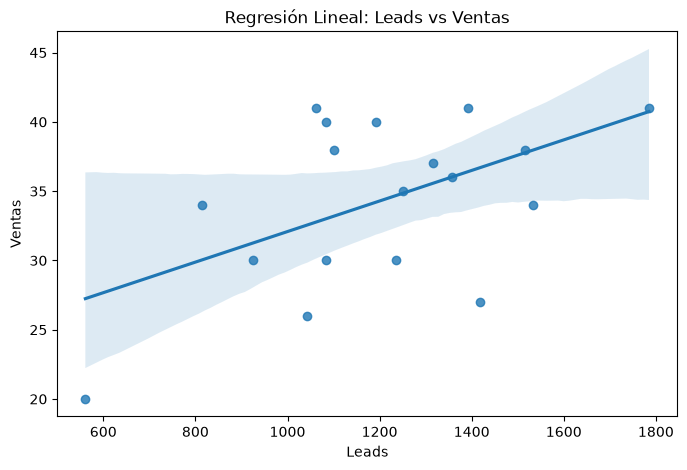

In [35]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=marketing_reg,
    x='Leads',
    y='Ventas'
)

plt.title('Regresión Lineal: Leads vs Ventas')
plt.xlabel('Leads')
plt.ylabel('Ventas')

plt.show()

In [36]:
resultados_regresion = pd.DataFrame({
    'Regresion': [
        'Provision → Ventas',
        'Provision → Leads',
        'Leads → Ventas'
    ],
    'Correlacion': [
        marketing_reg['Provision'].corr(marketing_reg['Ventas']),
        marketing_reg['Provision'].corr(marketing_reg['Leads']),
        marketing_reg['Leads'].corr(marketing_reg['Ventas'])
    ],
    'R2': [
        r2_1,
        r2_2,
        r2_3
    ]
})

resultados_regresion.round(3)

,Regresion,Correlacion,R2
0,Provision → Ventas,0.646,0.417
1,Provision → Leads,0.660,0.436
2,Leads → Ventas,0.523,0.274
